In [11]:
import pandas as pd
ruta1 = pd.read_csv('ruta_plana.csv')
ruta2 = pd.read_csv('ruta_montana.csv')
ruta1_cords = pd.read_csv('C:\\Users\\Remote1\\Desktop\\Process_Geotab_Data\\processed_data\\2026-03-12\\gps.csv')
ruta2_cords = pd.read_csv('C:\\Users\\Remote1\\Desktop\\Process_Geotab_Data\\processed_data\\2026-03-06\\gps.csv')

# def align_route_starts(route_ref, route_to_align, lat_col='latitude', lon_col='longitude'):
#     """Reverse route_to_align if needed so its origin matches route_ref origin, then snap first point."""
#     ref_start = route_ref.loc[0, [lat_col, lon_col]].to_numpy(dtype=float)
#     align_start = route_to_align.loc[0, [lat_col, lon_col]].to_numpy(dtype=float)
#     align_end = route_to_align.loc[route_to_align.index[-1], [lat_col, lon_col]].to_numpy(dtype=float)

#     dist_to_start = ((align_start - ref_start) ** 2).sum()
#     dist_to_end = ((align_end - ref_start) ** 2).sum()
#     if dist_to_end < dist_to_start:
#         route_to_align = route_to_align.iloc[::-1].reset_index(drop=True)

#     route_to_align = route_to_align.copy()
#     route_to_align.loc[0, lat_col] = route_ref.loc[0, lat_col]
#     route_to_align.loc[0, lon_col] = route_ref.loc[0, lon_col]
#     return route_to_align

# ruta2_cords = align_route_starts(ruta1_cords, ruta2_cords)
# # Force both routes to end at the same point
# ruta2_cords.loc[ruta2_cords.index[-1], 'latitude'] = ruta1_cords.loc[ruta1_cords.index[-1], 'latitude']
# ruta2_cords.loc[ruta2_cords.index[-1], 'longitude'] = ruta1_cords.loc[ruta1_cords.index[-1], 'longitude']

In [12]:
ruta1_cords.head()

,datetime,latitude,longitude
0,2026-03-12 08:43:18.372,9.93720,-84.04373
1,2026-03-12 08:43:18.395,9.93720,-84.04373
2,2026-03-12 08:43:23.000,9.93720,-84.04373
3,2026-03-12 08:43:37.000,9.93713,-84.04377
4,2026-03-12 08:44:23.333,9.93713,-84.04377


In [13]:
ruta2_cords.head()

,datetime,latitude,longitude
0,2026-03-06 08:26:44.394,9.93678,-84.04376
1,2026-03-06 08:26:44.414,9.93678,-84.04376
2,2026-03-06 08:26:45.000,9.93673,-84.04379
3,2026-03-06 08:27:30.162,9.93673,-84.04379
4,2026-03-06 08:27:39.000,9.93673,-84.04379


In [14]:
import folium
import numpy as np
from math import radians, sin, cos, sqrt, atan2

# --- Distance helpers ---
def haversine_m(lat1, lon1, lat2, lon2):
    R = 6371000.0
    la1, lo1 = radians(lat1), radians(lon1)
    la2, lo2 = radians(lat2), radians(lon2)
    dlat, dlon = la2 - la1, lo2 - lo1
    a = sin(dlat / 2) ** 2 + cos(la1) * cos(la2) * sin(dlon / 2) ** 2
    return 2 * R * atan2(sqrt(a), sqrt(1 - a))

def cumulative_distance_km(points):
    d = [0.0]
    for i in range(1, len(points)):
        lat1, lon1 = points[i - 1]
        lat2, lon2 = points[i]
        d.append(d[-1] + haversine_m(lat1, lon1, lat2, lon2) / 1000.0)
    return np.array(d)

# Route coordinates
ruta1_points = list(zip(ruta1_cords['latitude'], ruta1_cords['longitude']))
ruta2_points = list(zip(ruta2_cords['latitude'], ruta2_cords['longitude']))

dist1 = cumulative_distance_km(ruta1_points)
dist2 = cumulative_distance_km(ruta2_points)

# Center map on midpoint
all_lats = list(ruta1_cords['latitude']) + list(ruta2_cords['latitude'])
all_lons = list(ruta1_cords['longitude']) + list(ruta2_cords['longitude'])
center_lat = (min(all_lats) + max(all_lats)) / 2
center_lon = (min(all_lons) + max(all_lons)) / 2

# Build map with multiple base layers
m = folium.Map(location=[center_lat, center_lon], zoom_start=11, tiles=None)
folium.TileLayer('OpenStreetMap', name='OpenStreetMap').add_to(m)
folium.TileLayer('CartoDB Positron', name='Carto Light').add_to(m)
folium.TileLayer(
    tiles='https://{s}.tile.opentopomap.org/{z}/{x}/{y}.png',
    name='Topo',
    attr='Map data: OpenStreetMap contributors, SRTM | Map style: OpenTopoMap (CC-BY-SA)'
).add_to(m)

# Route layers
route1_group = folium.FeatureGroup(name='Route #1', show=True)
route2_group = folium.FeatureGroup(name='Route #2', show=True)

folium.PolyLine(
    ruta1_points,
    color='#2166AC',
    weight=5,
    opacity=0.9,
    tooltip=f"Route #1: {dist1[-1]:.2f} km"
).add_to(route1_group)

folium.PolyLine(
    ruta2_points,
    color='#B2182B',
    weight=5,
    opacity=0.85,
    dash_array='8,6',
    tooltip=f"Route #2: {dist2[-1]:.2f} km"
).add_to(route2_group)

# Start / End markers and always-visible labels
folium.Marker(
    ruta1_points[0],
    popup='Route #1 - Start',
    icon=folium.Icon(color='blue', icon='play', prefix='fa')
).add_to(route1_group)
folium.Marker(
    ruta1_points[-1],
    popup='Route #1 - End',
    icon=folium.Icon(color='blue', icon='stop', prefix='fa')
).add_to(route1_group)

folium.Marker(
    ruta2_points[0],
    popup='Route #2 - Start',
    icon=folium.Icon(color='red', icon='play', prefix='fa')
).add_to(route2_group)
folium.Marker(
    ruta2_points[-1],
    popup='Route #2 - End',
    icon=folium.Icon(color='red', icon='stop', prefix='fa')
).add_to(route2_group)

# Always-visible text labels
folium.Marker(
    ruta1_points[0],
    icon=folium.DivIcon(html="""<div style='font-size:11px;font-weight:700;color:#2166AC;background:white;padding:1px 4px;border:1px solid #2166AC;border-radius:4px;'>Route #1 Start</div>""")
).add_to(route1_group)
folium.Marker(
    ruta1_points[-1],
    icon=folium.DivIcon(html="""<div style='font-size:11px;font-weight:700;color:#2166AC;background:white;padding:1px 4px;border:1px solid #2166AC;border-radius:4px;'>Route #1 End</div>""")
).add_to(route1_group)
folium.Marker(
    ruta2_points[0],
    icon=folium.DivIcon(html="""<div style='font-size:11px;font-weight:700;color:#B2182B;background:white;padding:1px 4px;border:1px solid #B2182B;border-radius:4px;'>Route #2 Start</div>""")
).add_to(route2_group)
folium.Marker(
    ruta2_points[-1],
    icon=folium.DivIcon(html="""<div style='font-size:11px;font-weight:700;color:#B2182B;background:white;padding:1px 4px;border:1px solid #B2182B;border-radius:4px;'>Route #2 End</div>""")
).add_to(route2_group)

# Distance markers every 10 km
for pts, dists, color, group in [
    (ruta1_points, dist1, '#2166AC', route1_group),
    (ruta2_points, dist2, '#B2182B', route2_group),
]:
    max_km = int(dists[-1])
    for km in range(10, max_km + 1, 10):
        idx = int(np.argmin(np.abs(dists - km)))
        folium.CircleMarker(
            location=pts[idx],
            radius=4,
            color=color,
            fill=True,
            fill_opacity=0.9,
            popup=f"{km} km"
        ).add_to(group)
        folium.Marker(
            pts[idx],
            icon=folium.DivIcon(html=f"""<div style='font-size:10px;font-weight:700;color:{color};'>{km} km</div>""")
        ).add_to(group)

route1_group.add_to(m)
route2_group.add_to(m)

# Fit map to all route points
m.fit_bounds([[min(all_lats), min(all_lons)], [max(all_lats), max(all_lons)]])

# Legend with route metrics
legend_html = f"""
<div style="position: fixed; bottom: 30px; left: 30px; z-index: 1000; background-color: white;
     padding: 10px 12px; border: 2px solid #777; border-radius: 6px; font-size: 13px;">
     <b>Route Comparison</b><br>
     <i style="background: #2166AC; width: 20px; height: 3px; display: inline-block; margin-right: 5px;"></i> Route #1: {dist1[-1]:.2f} km<br>
     <i style="background: #B2182B; width: 20px; height: 3px; display: inline-block; margin-right: 5px;"></i> Route #2: {dist2[-1]:.2f} km<br>
     <span style="font-size:11px;color:#444;">Markers every 10 km</span>
</div>
"""
m.get_root().html.add_child(folium.Element(legend_html))
folium.LayerControl(collapsed=False).add_to(m)

m.save('rutas_map.html')
print('Improved map saved to rutas_map.html')
m

Improved map saved to rutas_map.html


In [15]:
routes_export = pd.concat([
    pd.DataFrame({
        'route': 'Route #1',
        'latitude': ruta1_cords['latitude'].values,
        'longitude': ruta1_cords['longitude'].values,
        'distance_km': dist1,
    }),
    pd.DataFrame({
        'route': 'Route #2',
        'latitude': ruta2_cords['latitude'].values,
        'longitude': ruta2_cords['longitude'].values,
        'distance_km': dist2,
    }),
], ignore_index=True)

routes_export.to_csv('route_points_comparison.csv', index=False)
print('Saved route_points_comparison.csv')
routes_export.head()

Saved route_points_comparison.csv


,route,latitude,longitude,distance_km
0,Route #1,9.93720,-84.04373,0.000000
1,Route #1,9.93720,-84.04373,0.000000
2,Route #1,9.93720,-84.04373,0.000000
3,Route #1,9.93713,-84.04377,0.008932
4,Route #1,9.93713,-84.04377,0.008932


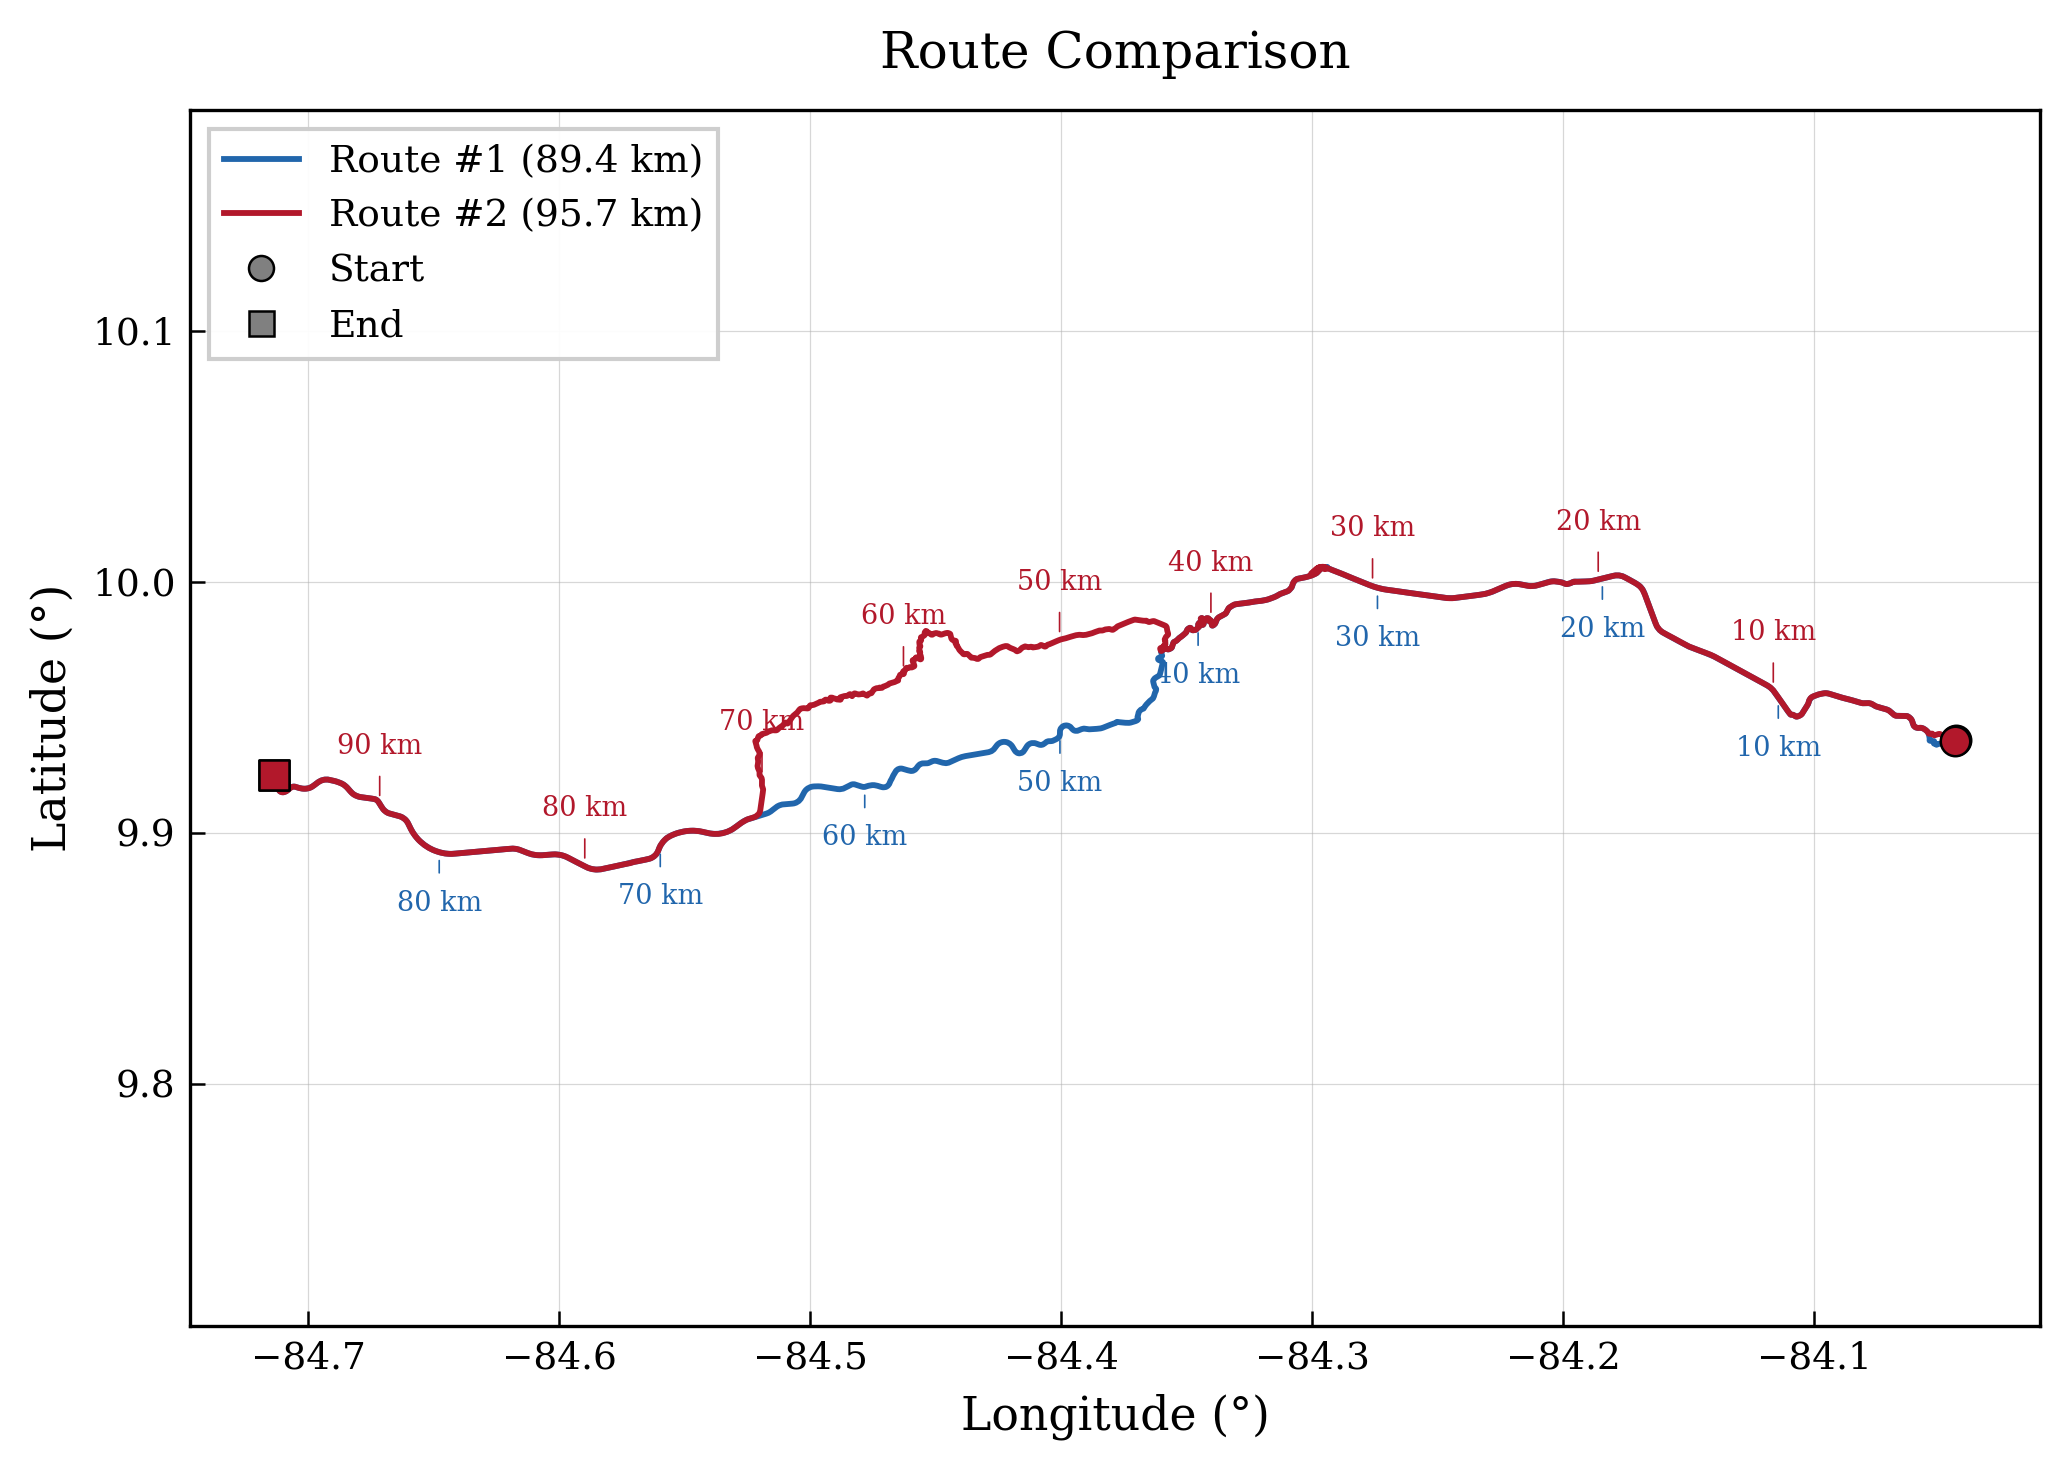

Route #1 total distance: 89.43 km
Route #2 total distance: 95.73 km


In [16]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
from matplotlib.lines import Line2D

# --- Paper-quality style ---
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 10,
    'axes.labelsize': 11,
    'axes.titlesize': 12,
    'legend.fontsize': 9,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'figure.dpi': 300,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'axes.linewidth': 0.8,
    'xtick.major.width': 0.6,
    'ytick.major.width': 0.6,
    'lines.linewidth': 1.2,
})

# --- Haversine helper ---
def haversine(lat1, lon1, lat2, lon2):
    R = 6371000  # metres
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    dphi = np.radians(lat2 - lat1)
    dlambda = np.radians(lon2 - lon1)
    a = np.sin(dphi / 2)**2 + np.cos(phi1) * np.cos(phi2) * np.sin(dlambda / 2)**2
    return R * 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))

# --- Compute cumulative distance along GPS traces (km) ---
def cum_distance_km(lats, lons):
    d = np.zeros(len(lats))
    for i in range(1, len(lats)):
        d[i] = d[i-1] + haversine(lats[i-1], lons[i-1], lats[i], lons[i])
    return d / 1000.0

dist1 = cum_distance_km(ruta1_cords['latitude'].values, ruta1_cords['longitude'].values)
dist2 = cum_distance_km(ruta2_cords['latitude'].values, ruta2_cords['longitude'].values)

# ------------------------------
# FIGURE 1 - Route Map (lat/lon, paper style)
# ------------------------------
fig, ax = plt.subplots(figsize=(7, 5))

ax.plot(ruta1_cords['longitude'], ruta1_cords['latitude'],
        color='#2166AC', linewidth=1.4, label=f'Route #1 ({dist1[-1]:.1f} km)', zorder=3)
ax.plot(ruta2_cords['longitude'], ruta2_cords['latitude'],
        color='#B2182B', linewidth=1.4, label=f'Route #2 ({dist2[-1]:.1f} km)', zorder=3)

# Start / End markers
ax.scatter(ruta1_cords['longitude'].iloc[0], ruta1_cords['latitude'].iloc[0],
           marker='o', s=50, color='#2166AC', edgecolors='k', linewidths=0.6, zorder=5)
ax.scatter(ruta1_cords['longitude'].iloc[-1], ruta1_cords['latitude'].iloc[-1],
           marker='s', s=50, color='#2166AC', edgecolors='k', linewidths=0.6, zorder=5)
ax.scatter(ruta2_cords['longitude'].iloc[0], ruta2_cords['latitude'].iloc[0],
           marker='o', s=50, color='#B2182B', edgecolors='k', linewidths=0.6, zorder=5)
ax.scatter(ruta2_cords['longitude'].iloc[-1], ruta2_cords['latitude'].iloc[-1],
           marker='s', s=50, color='#B2182B', edgecolors='k', linewidths=0.6, zorder=5)

# Distance annotations every ~10 km along each route
for coords, dist, color, offset_y in [
    (ruta1_cords, dist1, '#2166AC', -0.006),
    (ruta2_cords, dist2, '#B2182B',  0.004)
]:
    prev_km = 0
    for i in range(len(dist)):
        km = int(dist[i])
        if km >= prev_km + 10:
            ax.annotate(f'{km} km',
                        xy=(coords['longitude'].iloc[i], coords['latitude'].iloc[i]),
                        xytext=(0, 12 if offset_y > 0 else -14),
                        textcoords='offset points',
                        fontsize=6.5, color=color, ha='center',
                        arrowprops=dict(arrowstyle='-', color=color, lw=0.4))
            prev_km = km

# Custom legend with start/end markers
legend_elements = [
    Line2D([0], [0], color='#2166AC', lw=1.4, label=f'Route #1 ({dist1[-1]:.1f} km)'),
    Line2D([0], [0], color='#B2182B', lw=1.4, label=f'Route #2 ({dist2[-1]:.1f} km)'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='gray',
           markersize=6, markeredgecolor='k', markeredgewidth=0.6, label='Start'),
    Line2D([0], [0], marker='s', color='w', markerfacecolor='gray',
           markersize=6, markeredgecolor='k', markeredgewidth=0.6, label='End'),
]
ax.legend(handles=legend_elements, loc='upper left', frameon=True,
          edgecolor='#cccccc', fancybox=False, framealpha=0.95)

ax.set_xlabel('Longitude (°)')
ax.set_ylabel('Latitude (°)')
ax.set_title('Route Comparison', pad=10)
ax.set_aspect('equal', adjustable='datalim')
ax.grid(True, linewidth=0.3, alpha=0.5)
ax.tick_params(direction='in')

fig.tight_layout()
fig.savefig('route_map.png')
fig.savefig('route_map.pdf')
fig.savefig('route_map.svg')
plt.show()
print(f'Route #1 total distance: {dist1[-1]:.2f} km')
print(f'Route #2 total distance: {dist2[-1]:.2f} km')

In [17]:
ruta2

,segment_id,Hour,Trip_distance,Delta_d,Hum,OAT[DegC]_API,precipMM,Slope,primary,residential,secondary,crossing,tertiary,give_way,Voltage,Current,Power,SoC
0,0,8,100.363613,100.363613,75.0,21.0,0.0,0.570863,0,0,0,0,0,0,372.991518,-3.790905,-1413.511338,76.578220
1,1,8,200.715113,100.351500,75.0,21.0,0.0,0.000000,0,0,0,0,0,0,372.979245,-10.722689,-3998.348485,76.568409
2,2,8,300.970235,100.255123,75.0,21.0,0.0,0.000000,0,1,0,0,0,0,372.970350,-15.746698,-5871.783550,76.561299
3,3,8,404.513920,103.543684,75.0,21.0,0.0,-6.610695,0,1,0,0,0,0,372.956668,-23.474354,-8753.398295,76.550362
4,4,8,506.361603,101.847684,75.0,21.0,0.0,0.000000,0,1,0,0,0,0,372.944440,-30.380737,-11328.763636,76.540587
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
927,927,10,95393.620843,104.183166,48.0,31.0,0.0,0.000000,0,0,0,0,0,0,356.000000,57.156223,20347.615385,52.805000
928,928,10,95497.634216,104.013373,48.0,31.0,0.0,0.000000,0,0,0,0,0,0,356.000000,77.562266,27612.166774,52.805000
929,929,10,95600.564957,102.930740,48.0,31.0,0.0,0.000000,0,0,0,0,0,0,356.000000,-36.316896,-12928.815126,52.805000
930,930,10,95701.711119,101.146162,48.0,31.0,0.0,0.000000,0,1,0,0,0,0,356.000000,-42.825843,-15246.000000,52.805000


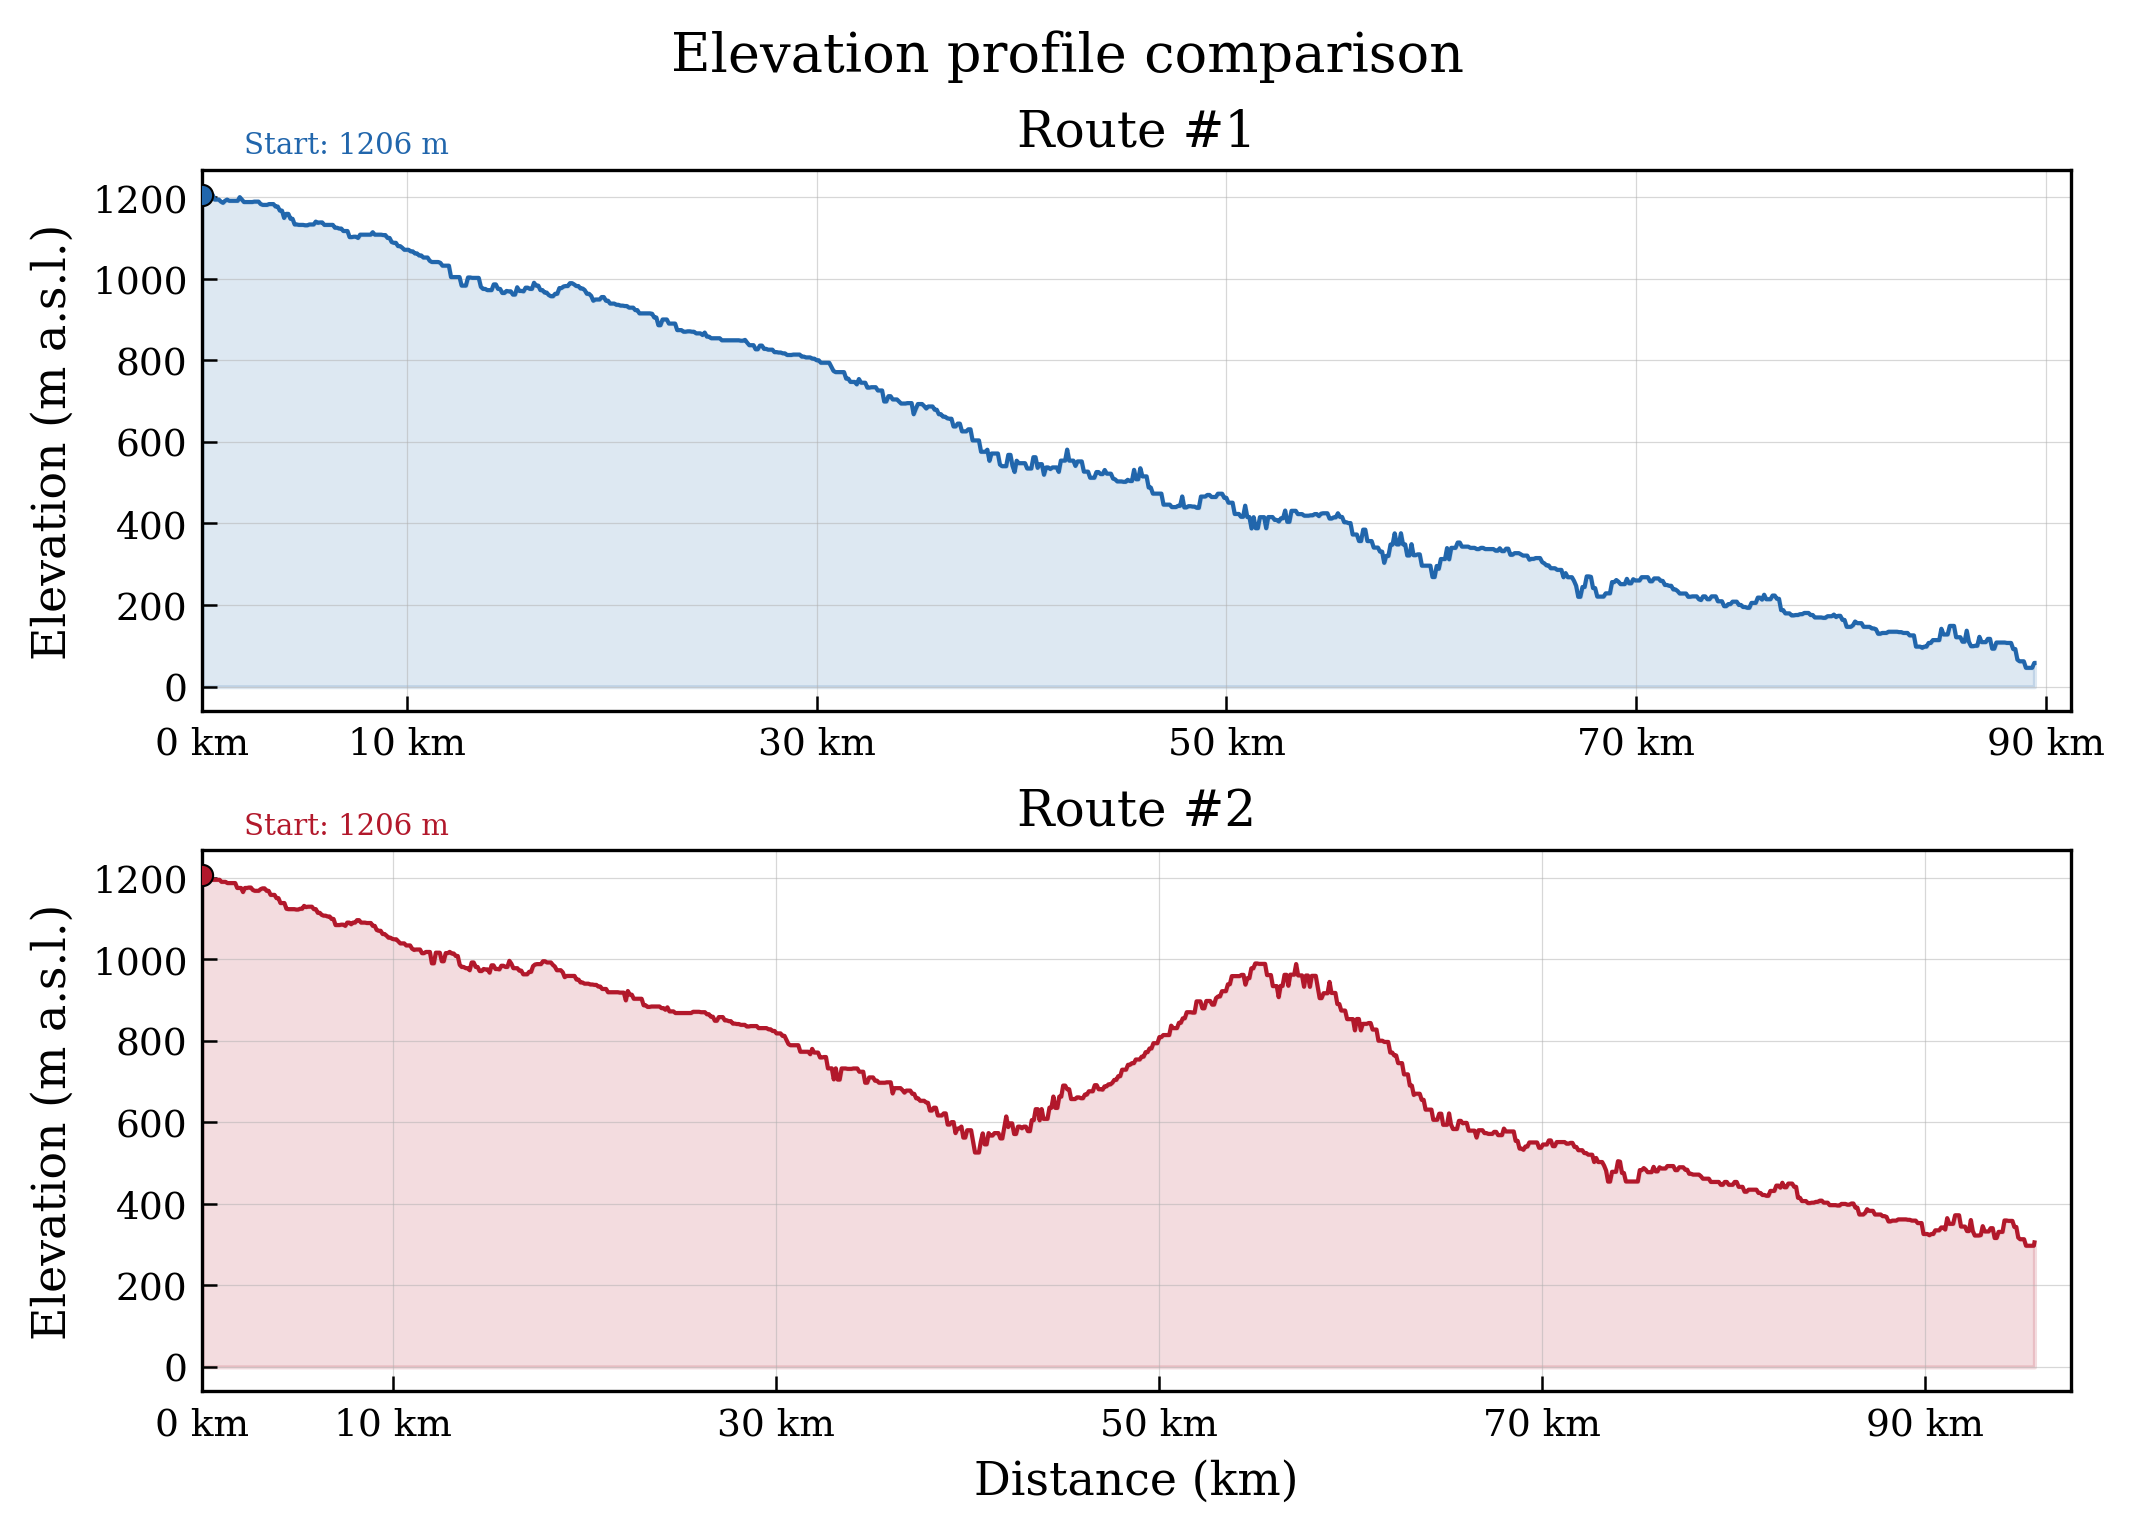

Common start elevation: 1206 m
Route #1 - Total climb: 1521 m  |  Total descent: -2669 m  |  Net: -1148 m
Route #2 - Total climb: 1960 m  |  Total descent: -2861 m  |  Net: -901 m


In [18]:
# ------------------------------
# FIGURE 2 - Elevation Profile
# ------------------------------

# Reconstruct elevation from Slope (degrees) and segment length (Delta_d)
# Elevation change per segment: Dz = Delta_d * tan(slope_rad)
# Since both routes start at the same coordinate, they share one start elevation.
ELEV_START = 1206.0  # m a.s.l. at the common start point

slope_r1 = ruta1['Slope'].values
delta_d_r1 = ruta1['Delta_d'].values
dz_r1 = delta_d_r1 * np.tan(np.radians(slope_r1))
elev_r1 = ELEV_START + np.concatenate([[0], np.cumsum(dz_r1)])
dist_seg_r1 = np.concatenate([[0], ruta1['Trip_distance'].values]) / 1000.0  # km

slope_r2 = ruta2['Slope'].values
delta_d_r2 = ruta2['Delta_d'].values
dz_r2 = delta_d_r2 * np.tan(np.radians(slope_r2))
elev_r2 = ELEV_START + np.concatenate([[0], np.cumsum(dz_r2)])
dist_seg_r2 = np.concatenate([[0], ruta2['Trip_distance'].values]) / 1000.0  # km

# Guardrail: both curves must start at the same elevation.
if not np.isclose(elev_r1[0], elev_r2[0], atol=1e-9):
    raise ValueError(f'Start elevation mismatch: {elev_r1[0]:.3f} vs {elev_r2[0]:.3f}')

def annotate_extrema(ax, dist, elev, color, start_label):
    i_max = int(np.argmax(elev))
    n = len(elev)

    # Start point marker and label
    ax.scatter(dist[0], elev[0], s=26, color=color, edgecolors='k', linewidths=0.5, zorder=6)
    ax.annotate(
        start_label,
        xy=(dist[0], elev[0]),
        xytext=(10, 10),
        textcoords='offset points',
        fontsize=7,
        color=color,
        ha='left',
        bbox=dict(facecolor='white', edgecolor='none', alpha=0.75, pad=1.5)
    )

    # Skip max annotation if max is too close to the start label region.
    near_start_max = (dist[i_max] - dist[0]) <= 3.0
    if not near_start_max:
        if i_max > int(0.85 * n):
            max_xytext = (-38, 8)
            max_ha = 'right'
        else:
            max_xytext = (8, 8)
            max_ha = 'left'
        ax.annotate(
            f'Max: {elev[i_max]:.0f} m',
            xy=(dist[i_max], elev[i_max]),
            xytext=max_xytext,
            textcoords='offset points',
            fontsize=7,
            color=color,
            ha=max_ha,
            bbox=dict(facecolor='white', edgecolor='none', alpha=0.75, pad=1.2)
        )

# Etiquetas de eje X personalizadas
from matplotlib.ticker import MultipleLocator, FixedLocator

km_ticks = [0, 10, 30, 50, 70, 90]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7, 5), sharex=False, constrained_layout=True)

# --- Route #1 ---
ax1.fill_between(dist_seg_r1, elev_r1, alpha=0.15, color='#2166AC')
ax1.plot(dist_seg_r1, elev_r1, color='#2166AC', linewidth=1.0)
ax1.set_ylabel('Elevation (m a.s.l.)')
ax1.set_title('Route #1', pad=6)
xpad1 = 0.02 * (dist_seg_r1[-1] - dist_seg_r1[0])
ax1.set_xlim(dist_seg_r1[0], dist_seg_r1[-1] + xpad1)
ax1.grid(True, linewidth=0.3, alpha=0.5)
ax1.tick_params(direction='in')
annotate_extrema(ax1, dist_seg_r1, elev_r1, '#2166AC', f'Start: {ELEV_START:.0f} m')
ax1.xaxis.set_major_locator(FixedLocator(km_ticks))
ax1.set_xticklabels([f'{km} km' for km in km_ticks])

# --- Route #2 ---
ax2.fill_between(dist_seg_r2, elev_r2, alpha=0.15, color='#B2182B')
ax2.plot(dist_seg_r2, elev_r2, color='#B2182B', linewidth=1.0)
ax2.set_xlabel('Distance (km)')
ax2.set_ylabel('Elevation (m a.s.l.)')
ax2.set_title('Route #2', pad=6)
xpad2 = 0.02 * (dist_seg_r2[-1] - dist_seg_r2[0])
ax2.set_xlim(dist_seg_r2[0], dist_seg_r2[-1] + xpad2)
ax2.grid(True, linewidth=0.3, alpha=0.5)
ax2.tick_params(direction='in')
annotate_extrema(ax2, dist_seg_r2, elev_r2, '#B2182B', f'Start: {ELEV_START:.0f} m')
ax2.xaxis.set_major_locator(FixedLocator(km_ticks))
ax2.set_xticklabels([f'{km} km' for km in km_ticks])

# Shared formatting
fig.suptitle('Elevation profile comparison', fontsize=13)
fig.savefig('elevation_profile.png')
fig.savefig('elevation_profile.pdf')
fig.savefig('elevation_profile.svg')
plt.show()

# Summary stats
gain_r1 = np.sum(dz_r1[dz_r1 > 0])
loss_r1 = np.sum(dz_r1[dz_r1 < 0])
gain_r2 = np.sum(dz_r2[dz_r2 > 0])
loss_r2 = np.sum(dz_r2[dz_r2 < 0])
print(f'Common start elevation: {ELEV_START:.0f} m')
print(f'Route #1 - Total climb: {gain_r1:.0f} m  |  Total descent: {loss_r1:.0f} m  |  Net: {gain_r1+loss_r1:.0f} m')
print(f'Route #2 - Total climb: {gain_r2:.0f} m  |  Total descent: {loss_r2:.0f} m  |  Net: {gain_r2+loss_r2:.0f} m')

In [19]:
# Diagnostic: Check route end alignment and elevation profile consistency
print('Route #1 end lat/lon:', ruta1_cords.iloc[-1][['latitude','longitude']].to_list())
print('Route #2 end lat/lon:', ruta2_cords.iloc[-1][['latitude','longitude']].to_list())
print('Route #1 shape:', ruta1_cords.shape)
print('Route #2 shape:', ruta2_cords.shape)
print('Route #1 last slope, delta_d:', ruta1['Slope'].iloc[-1], ruta1['Delta_d'].iloc[-1])
print('Route #2 last slope, delta_d:', ruta2['Slope'].iloc[-1], ruta2['Delta_d'].iloc[-1])
print('Route #1 final elevation:', elev_r1[-1])
print('Route #2 final elevation:', elev_r2[-1])

Route #1 end lat/lon: [np.float64(9.92309), np.float64(-84.71346)]
Route #2 end lat/lon: [np.float64(9.92308), np.float64(-84.71345)]
Route #1 shape: (1445, 3)
Route #2 shape: (1403, 3)
Route #1 last slope, delta_d: 0.0 9.18154926817176
Route #2 last slope, delta_d: 15.0 30.71911323628125
Route #1 final elevation: 58.21905566169721
Route #2 final elevation: 305.47191427583857
